In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("netflix_titles.csv")

In [38]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Know more about the dataset**

In [39]:
df.shape

(8807, 12)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**Data cleaning**

In [41]:
# check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [42]:
# remove duplicate
df.drop_duplicates(inplace=True)

In [43]:
# handle missing values
df["country"].fillna("Unknown", inplace=True)
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Unknown", inplace=True)
df["rating"].fillna("Unknown", inplace=True)

/tmp/ipykernel_3274/3391119135.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna("Unknown", inplace=True)
/tmp/ipykernel_3274/3391119135.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [44]:
# Convert date column
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

/tmp/ipykernel_3274/1362027584.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")


# **Summary statistics**

In [45]:
df.describe()

,date_added,release_year
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967168,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [46]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8797,8807.000000,8807,8804,8807,8807
unique,8807,2,8804,4529,7693,749,NaN,NaN,18,220,514,8775
top,s8807,Movie,9-Feb,Unknown,Unknown,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,2634,825,2818,NaN,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 05:59:08.436967168,2014.180198,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-02 00:00:00,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 00:00:00,2019.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN


# **Correlation Analysis**

In [47]:
# select numeric data only
df_numeric = df.select_dtypes(include=["int64", "float64"])
df_numeric.head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


In [48]:
df_numeric.corr()

,release_year
release_year,1.0


**Heatmap**

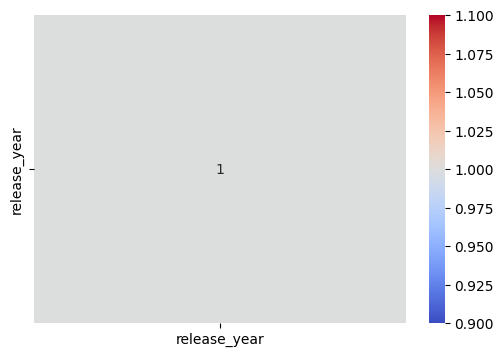

In [49]:
plt.figure(figsize=(6,4))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.show()

# **Trend identification**

**Movies vs TV Shows**

In [50]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


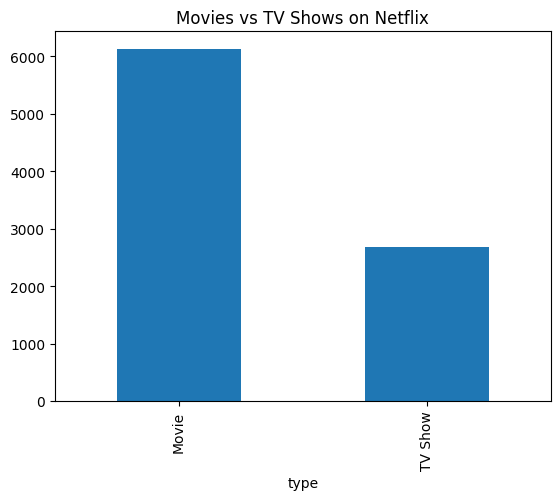

In [51]:
df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows on Netflix")
plt.show()

**Content over years**

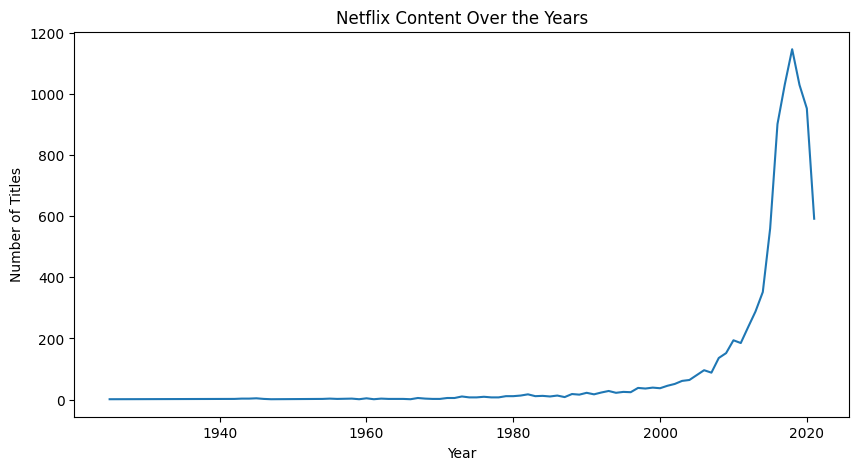

In [52]:
df["release_year"].value_counts().sort_index().plot(kind="line", figsize=(10,5))
plt.title("Netflix Content Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

**Top Countries**

In [53]:
df["country"].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


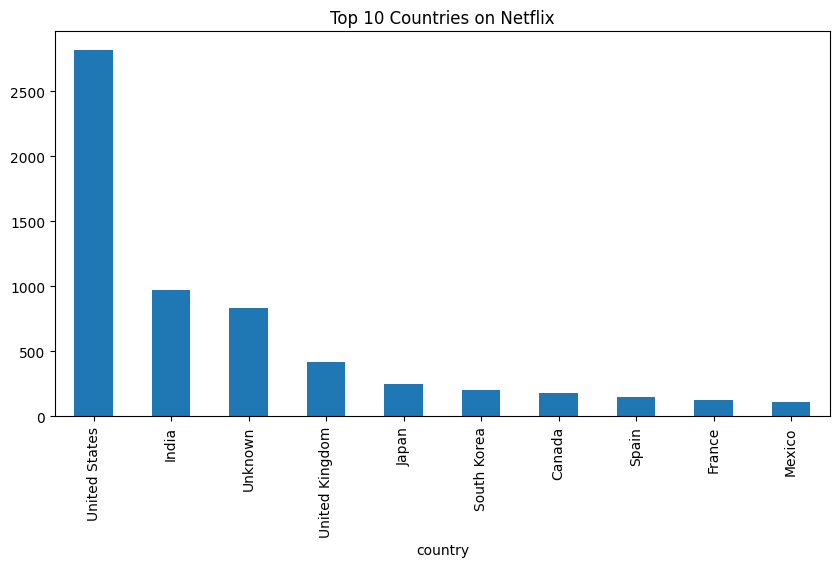

In [54]:
df["country"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries on Netflix")
plt.show()

**Ratings Distribution**

In [55]:
df["rating"].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


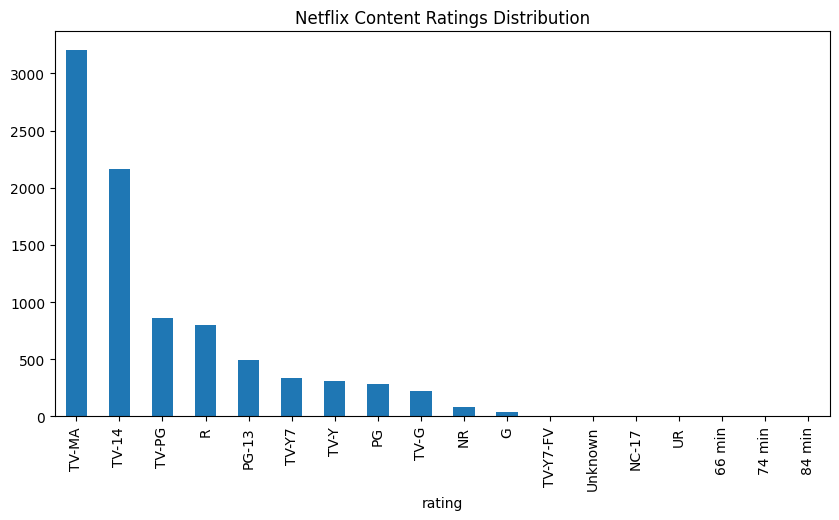

In [56]:
df["rating"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Netflix Content Ratings Distribution")
plt.show()